# Part 6: Probability & Distributions
Probability is the measure of the likelihood that an event will occur. In Data Science, we use these concepts to quantify uncertainty and make predictions.

## 1. Introduction & Types of Experiments
* **Deterministic Experiment:** The result is certain (e.g., heating water to 100°C).
* **Random Experiment:** The result is uncertain (e.g., tossing a coin, rolling a die).
* **Sample Space (S):** The set of all possible outcomes.
* **Event (E):** A subset of the sample space.

## 2. Rules & Conditional Probability
* **Addition Rule:** $P(A \cup B) = P(A) + P(B) - P(A \cap B)$
* **Multiplication Rule:** $P(A \cap B) = P(A) \times P(B|A)$
* **Conditional Probability:** The probability of an event occurring given that another event has already occurred.
  $$P(A|B) = \frac{P(A \cap B)}{P(B)}$$

## 3. Bayes’ Theorem
Bayes' Theorem describes the probability of an event based on prior knowledge of conditions that might be related to the event. This is the foundation of the **Naive Bayes Classifier**.
$$P(A|B) = \frac{P(B|A) \times P(A)}{P(B)}$$

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom, norm, uniform

# Simple Bayes Theorem Example: Testing for a Disease
# P(Disease) = 1%
# P(Pos | Disease) = 99% (Sensitivity)
# P(Pos | No Disease) = 5% (False Positive)

p_disease = 0.01
p_pos_given_disease = 0.99
p_pos_given_no_disease = 0.05
p_no_disease = 1 - p_disease

# Total probability of testing positive
p_positive = (p_pos_given_disease * p_disease) + (p_pos_given_no_disease * p_no_disease)

# Bayes' Theorem: P(Disease | Positive)
p_disease_given_pos = (p_pos_given_disease * p_disease) / p_positive

print(f"Probability of actually having the disease given a positive test: {p_disease_given_pos:.2%}")

Probability of actually having the disease given a positive test: 16.67%


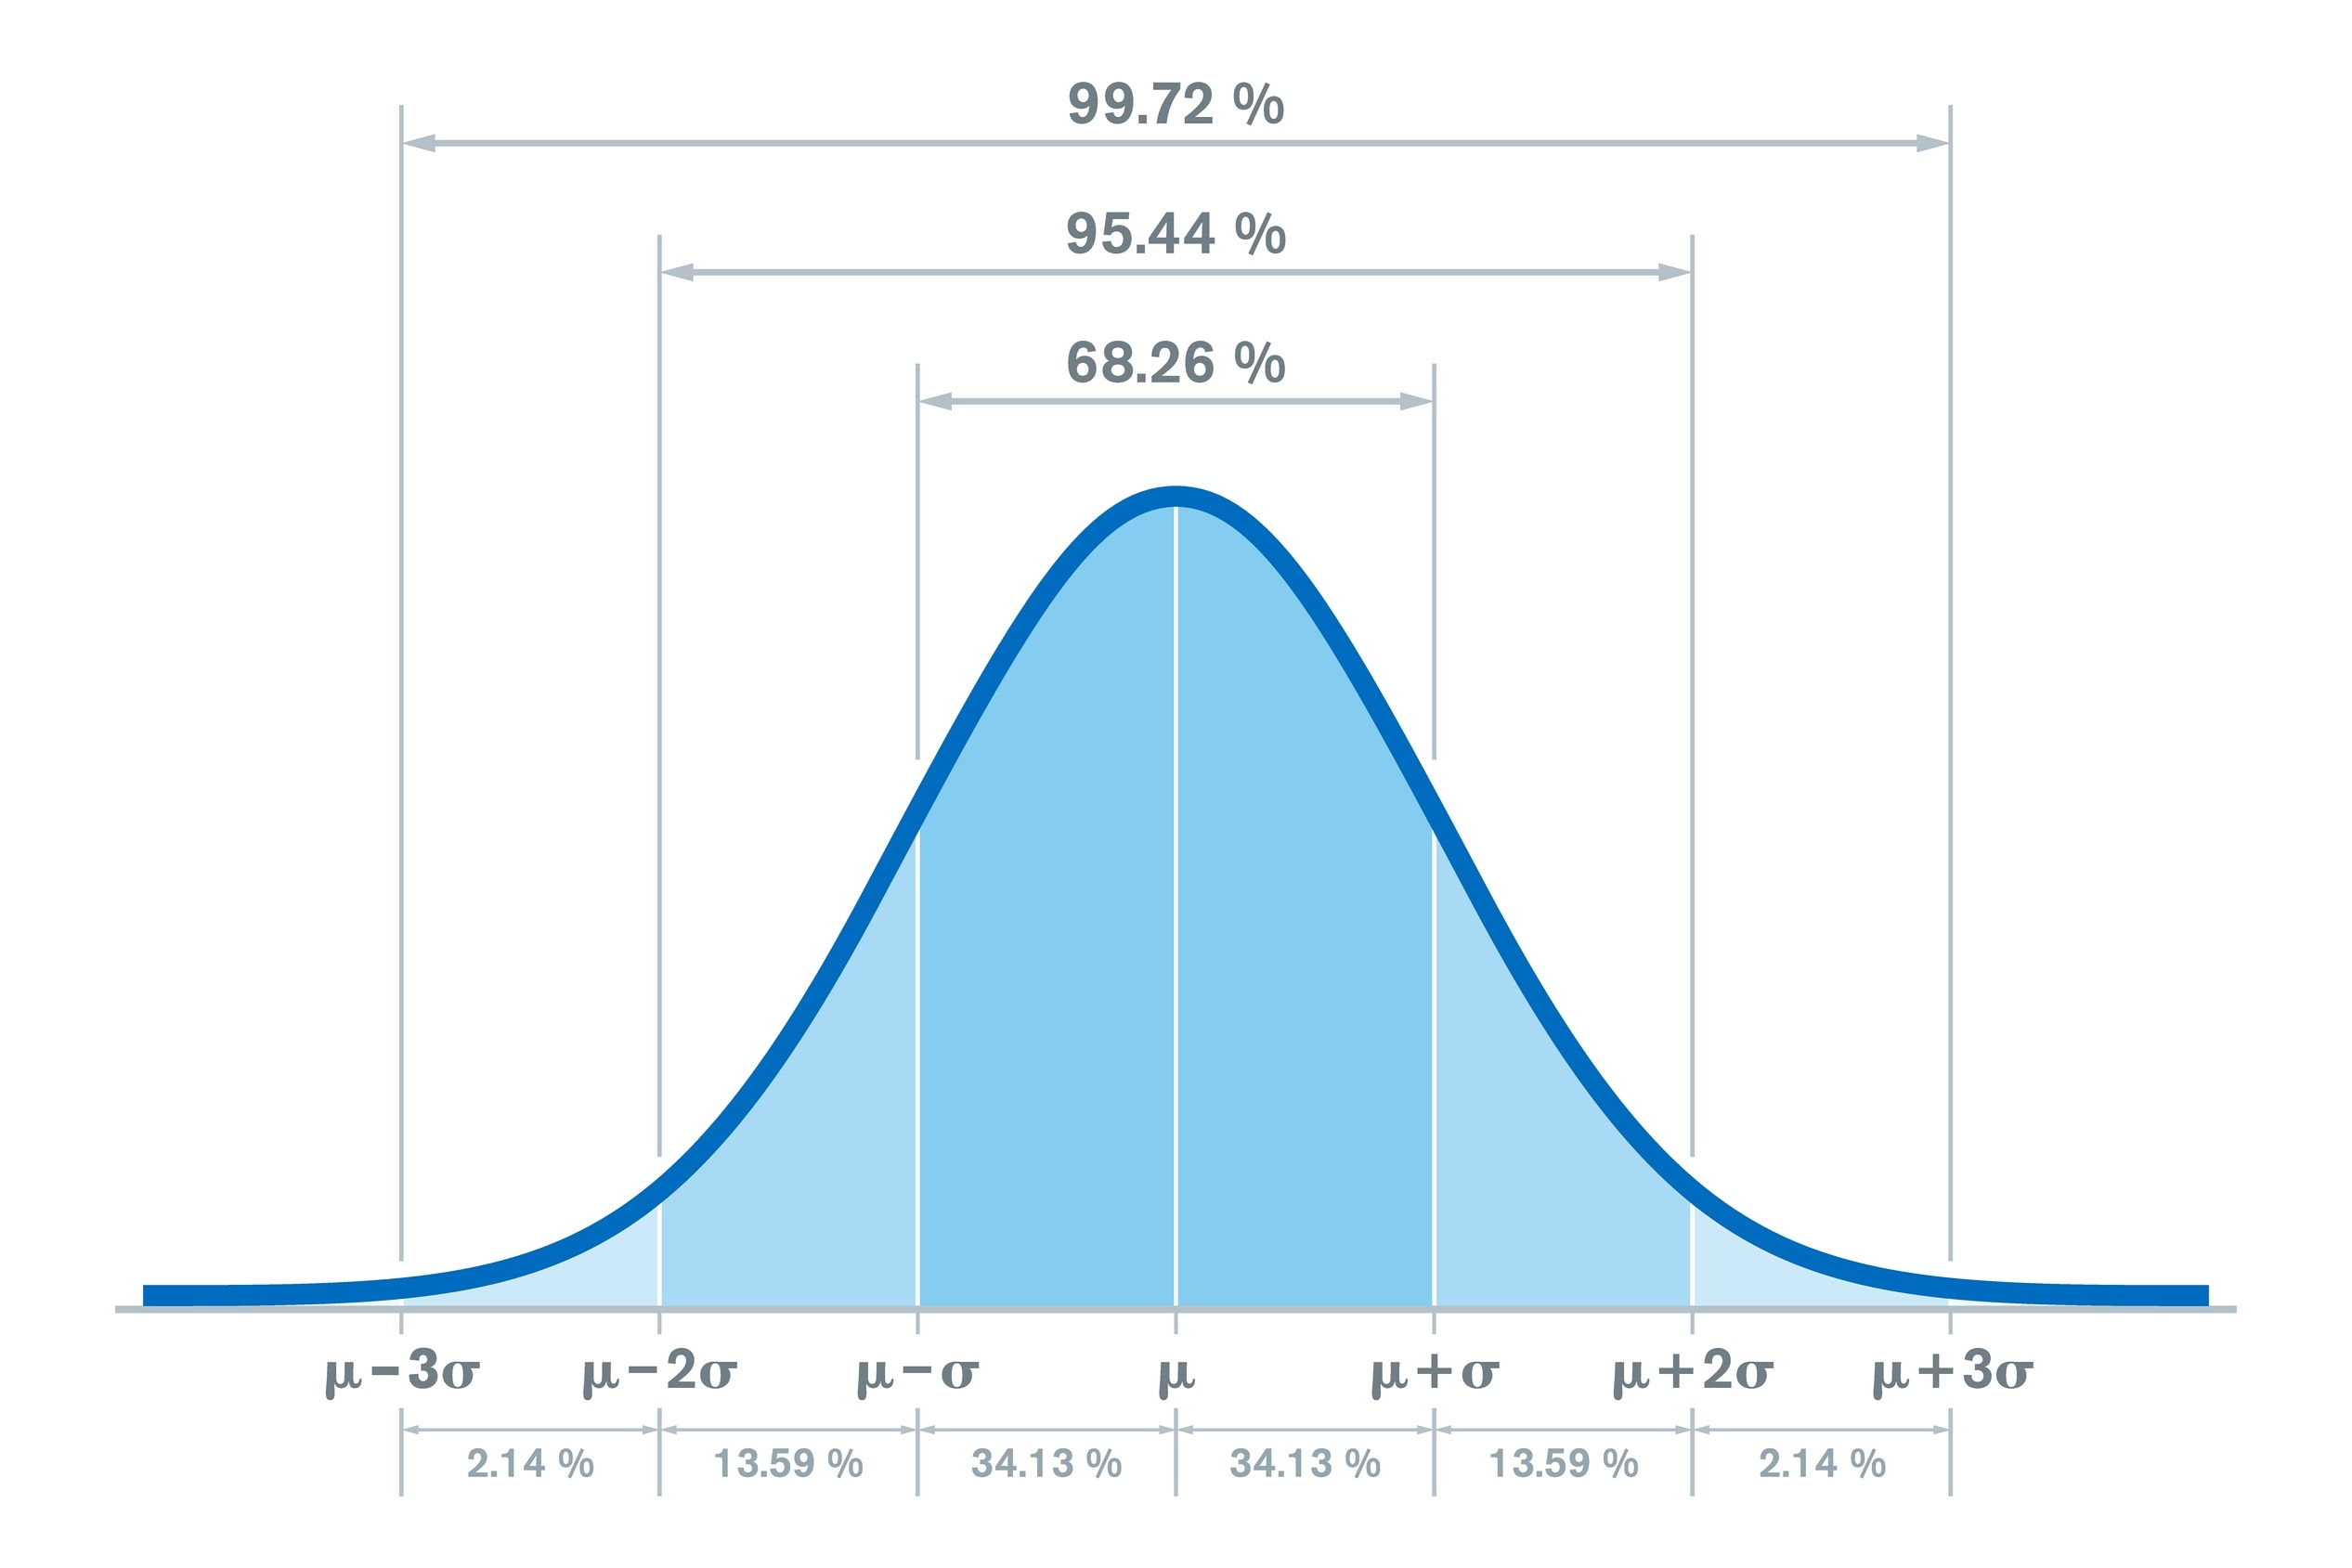

# Part 7: Probability Distributions & CLT
Distributions describe how the values of a random variable are spread.

### 1. Uniform Distribution
Every outcome is equally likely (e.g., rolling a fair die).
### 2. Binomial Distribution
Discrete distribution for "success/failure" experiments (e.g., number of heads in 10 coin flips).
### 3. Normal (Gaussian) Distribution
The "Bell Curve." Most natural phenomena follow this (height, weight, IQ).

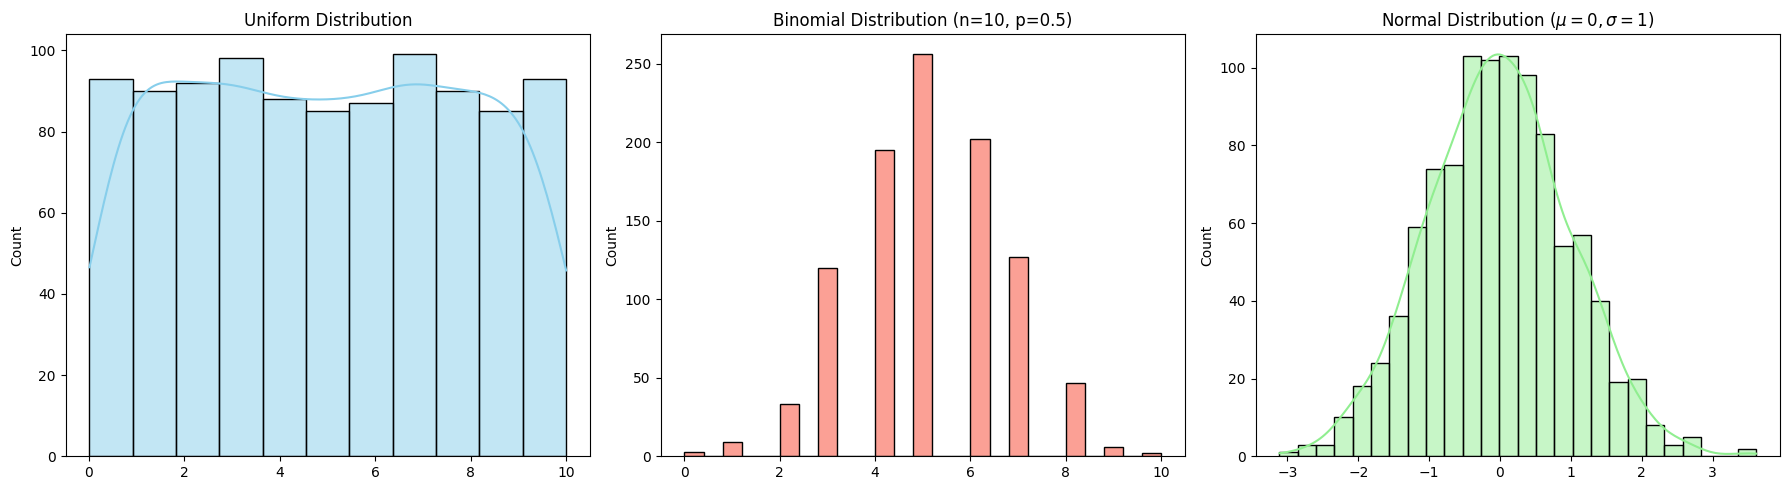

In [5]:
# Visualizing Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Uniform Distribution
u_data = uniform.rvs(size=1000, loc=0, scale=10)
sns.histplot(u_data, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Uniform Distribution')

# 2. Binomial Distribution (n=10 flips, p=0.5 success)
b_data = binom.rvs(n=10, p=0.5, size=1000)
sns.histplot(b_data, kde=False, ax=axes[1], color='salmon')
axes[1].set_title('Binomial Distribution (n=10, p=0.5)')

# 3. Normal Distribution (mean=0, std=1)
n_data = norm.rvs(loc=0, scale=1, size=1000)
sns.histplot(n_data, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Normal Distribution ($\mu=0, \sigma=1$)')

plt.tight_layout()
plt.show()

## 4. Central Limit Theorem (CLT)
The CLT states that if you take enough samples from **any** distribution, the mean of those samples will follow a **Normal Distribution**. This is why the Normal Distribution is so important in Data Science—it allows us to make inferences about populations even if the raw data is messy.

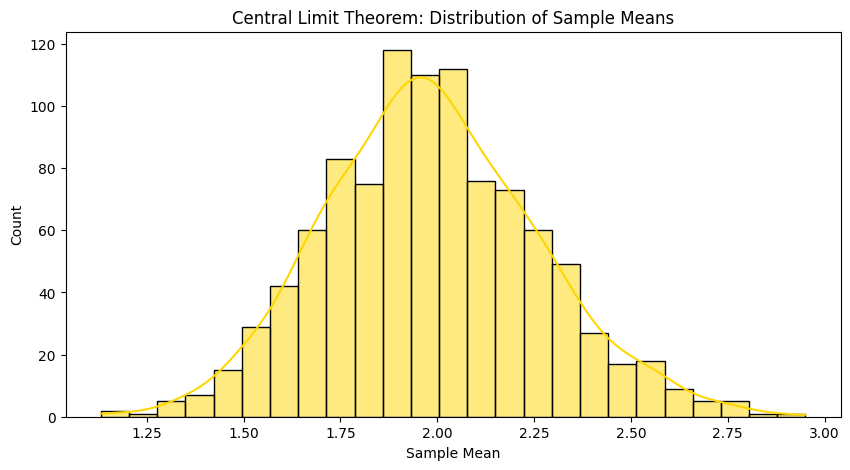

In [6]:
# CLT Demonstration
# We take a highly skewed distribution (Exponential)
skewed_data = np.random.exponential(scale=2, size=10000)

means = []
# Take 1000 samples of size 50 and calculate their means
for _ in range(1000):
    sample = np.random.choice(skewed_data, size=50)
    means.append(np.mean(sample))

plt.figure(figsize=(10, 5))
sns.histplot(means, kde=True, color='gold')
plt.title('Central Limit Theorem: Distribution of Sample Means')
plt.xlabel('Sample Mean')
plt.show()